In [4]:
import numpy as np
import h5py

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst

In [3]:
with h5py.File('./../DATA/Data_128.h5', 'r') as f:
    print("Keys in the HDF5 file:", list(f.keys()))
    # Read the snapshots dataset
    fmag_ext = f['fmag_ext'][:]
    kvecs = f['kvecs'][:]
        
    # Get the attributes nk_lin, nt and dt
    nk_lin = f.attrs['nk_lin']
    nt = f.attrs['nt']
    dt = f.attrs['dt']

Keys in the HDF5 file: ['fmag_ext', 'kvecs']


In [9]:
print(f'nk_lin: {nk_lin}')
print(f'nt: {nt}')
print(f'dt: {dt}')
print()
print(f'len(kvecs): {len(kvecs)}')
print(f'fmag_ext.shape:{fmag_ext.shape}')
print()
print(f'fmag_ext: {fmag_ext}')

nk_lin: 128
nt: 10000
dt: 0.005

len(kvecs): 16384
fmag_ext.shape:(100, 128, 128)

fmag_ext: [[[0.00043949 0.00050354 0.00057554 ... 0.00057554 0.00050354 0.00043949]
  [0.00050354 0.00057678 0.00065909 ... 0.00065909 0.00057678 0.00050354]
  [0.00057554 0.00065909 0.00075295 ... 0.00075295 0.00065909 0.00057554]
  ...
  [0.00057554 0.00065909 0.00075295 ... 0.00075295 0.00065909 0.00057554]
  [0.00050354 0.00057678 0.00065909 ... 0.00065909 0.00057678 0.00050354]
  [0.00043949 0.00050354 0.00057554 ... 0.00057554 0.00050354 0.00043949]]

 [[0.00043949 0.00050354 0.00057554 ... 0.00057554 0.00050354 0.00043949]
  [0.00050354 0.00057678 0.00065909 ... 0.00065909 0.00057678 0.00050354]
  [0.00057554 0.00065909 0.00075295 ... 0.00075295 0.00065909 0.00057554]
  ...
  [0.00057554 0.00065909 0.00075295 ... 0.00075295 0.00065909 0.00057554]
  [0.00050354 0.00057678 0.00065909 ... 0.00065909 0.00057678 0.00050354]
  [0.00043949 0.00050354 0.00057554 ... 0.00057554 0.00050354 0.00043949]]

 [[

In [8]:
fmag_ext = fmag_ext.reshape(100,nk_lin**2)
fmag_data = np.einsum('tk->kt',fmag_ext)


X = fmag_data[:,:-1]
Y = fmag_data[:,1: ]


truncamiento=-8


mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, orden_truncado=[0,truncamiento])

# Time evolution from DMD output
##dt = t[1] - t[0]
##omega_M = np.log(mu) / dt
##b_M = np.linalg.pinv(Phi_M) @ X[:, 0]
##time_dynamics_M = np.array([b_M * np.exp(omega_M * T) for T in t]).T
##X_dmd_M = Phi_M @ time_dynamics_M

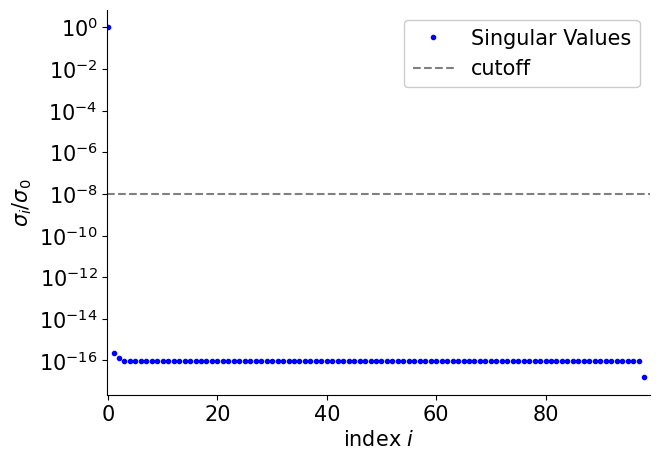

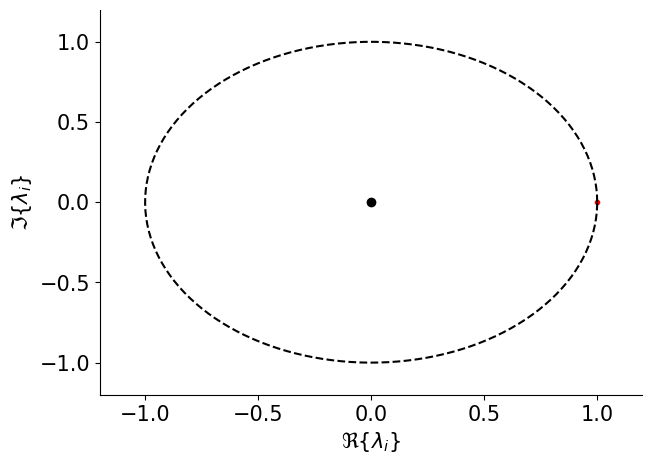

0

In [9]:
plotting.plot_singular_values(Sig2,10**(truncamiento))
plotting.plot_eigenvalues(mu)